<a href="https://colab.research.google.com/github/Ayush-thakur-01/Ml/blob/main/ASSIGHMENT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)

In [ ]:
import zipfile
import requests
import io

url = "https://archive.ics.uci.edu/static/public/850/raisin.zip"

z = zipfile.ZipFile(io.BytesIO(requests.get(url).content))
z.extractall("/content/raisin")

z2 = zipfile.ZipFile("/content/raisin/Raisin_Dataset.zip")
z2.extractall("/content/raisin/data")

print(z2.namelist())

['Raisin_Dataset/', 'Raisin_Dataset/Raisin_Dataset.arff', 'Raisin_Dataset/Raisin_Dataset.txt', 'Raisin_Dataset/Raisin_Dataset.xlsx']


In [ ]:
print(z.namelist())

['Raisin_Dataset.zip']


In [ ]:
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff(
    "/content/raisin/data/Raisin_Dataset/Raisin_Dataset.arff"
)

df = pd.DataFrame(data)

print(df.head())
print("Shape:", df.shape)

      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0  87524.0       442.246011       253.291155      0.819738     90546.0   
1  75166.0       406.690687       243.032436      0.801805     78789.0   
2  90856.0       442.267048       266.328318      0.798354     93717.0   
3  45928.0       286.540559       208.760042      0.684989     47336.0   
4  79408.0       352.190770       290.827533      0.564011     81463.0   

     Extent  Perimeter       Class  
0  0.758651   1184.040  b'Kecimen'  
1  0.684130   1121.786  b'Kecimen'  
2  0.637613   1208.575  b'Kecimen'  
3  0.699599    844.162  b'Kecimen'  
4  0.792772   1073.251  b'Kecimen'  
Shape: (900, 8)


In [ ]:
print(df.isnull().sum())

Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Perimeter          0
Class              0
dtype: int64


In [ ]:
df["Class"] = df["Class"].str.decode("utf-8")

df["Class"] = df["Class"].map({
    "Kecimen": 0,
    "Besni": 1
})

print(df["Class"].value_counts())

Class
0    450
1    450
Name: count, dtype: int64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

chi_scores, p_values = chi2(X, y)

chi_table = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi_scores,
    "P-Value": p_values
}).sort_values("Chi2 Score", ascending=False)

print(chi_table)

           Feature    Chi2 Score   P-Value
4       ConvexArea  6.412753e+06  0.000000
0             Area  6.097822e+06  0.000000
6        Perimeter  2.563142e+04  0.000000
1  MajorAxisLength  1.272952e+04  0.000000
2  MinorAxisLength  2.234351e+03  0.000000
3     Eccentricity  1.804260e+00  0.179198
5           Extent  8.791728e-02  0.766842


In [ ]:
least_important = chi_table.iloc[-1]["Feature"]

X = X.drop(columns=[least_important])

print("Removed feature:", least_important)
print("Remaining features:", list(X.columns))

Removed feature: Extent
Remaining features: ['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'Perimeter']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (720, 6)
Testing data: (180, 6)


In [ ]:
lr = LogisticRegression(max_iter=1000)
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=42)

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


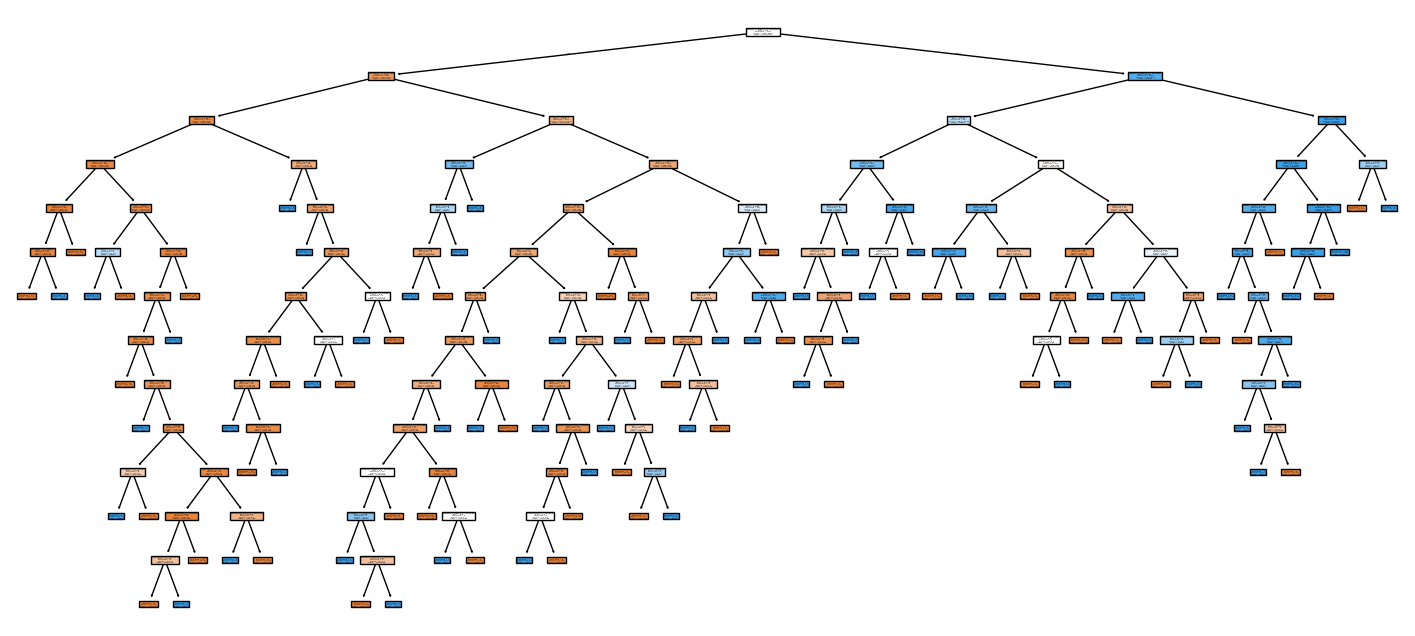

In [ ]:
plt.figure(figsize=(18, 8))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Kecimen", "Besni"],
    filled=True
)

plt.show()

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_dt = dt.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
models = {
    "Logistic Regression": y_pred_lr,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt
}

results = []

for name, pred in models.items():
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score"
])

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.916667   0.931034  0.900000  0.915254
1          Naive Bayes  0.855556   0.944444  0.755556  0.839506
2        Decision Tree  0.833333   0.833333  0.833333  0.833333


In [ ]:
for name, pred in models.items():
    print("\n", name)
    print(confusion_matrix(y_test, pred))


 Logistic Regression
[[84  6]
 [ 9 81]]

 Naive Bayes
[[86  4]
 [22 68]]

 Decision Tree
[[75 15]
 [15 75]]


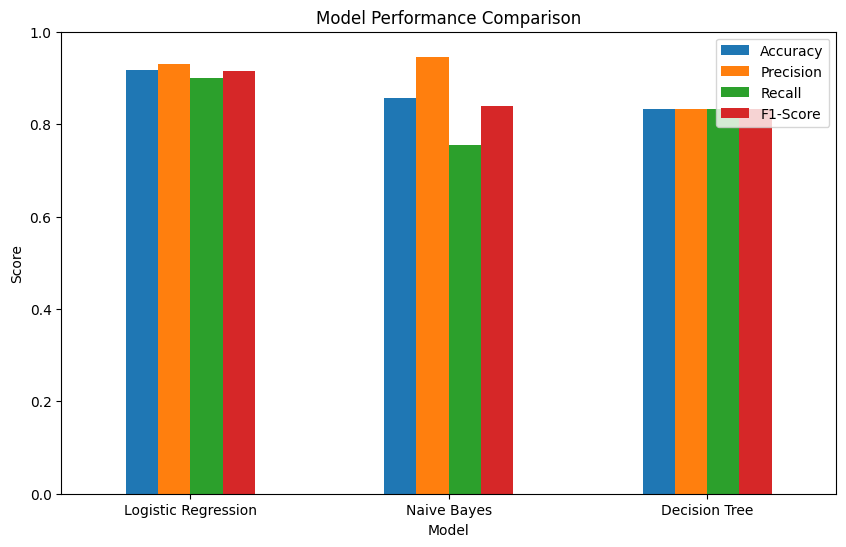

In [ ]:
results_df.set_index("Model").plot(kind="bar", figsize=(10, 6))

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.show()